<a href="https://colab.research.google.com/github/ahcamachod/2313-spark-trabajando-con-regresion/blob/clase-3/Spark_trabajando_con_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spark: Trabajando con Regresión**

# **Clase 1: Cargando los datos**
---

## Apache Spark - Introducción

### [Apache Spark](https://spark.apache.org/)

Apache Spark es una plataforma de computación en *cluster* que proporciona una API para programación distribuida para el procesamiento de datos a gran escala, similar al modelo *MapReduce*, pero diseñada para ser rápida en consultas interactivas y algoritmos iterativos.

Spark permite distribuir datos y tareas en clusters con múltiples nodos. Imagina cada nodo como un computador independiente. La división de los datos facilita el trabajo con conjuntos de datos muy grandes, ya que cada nodo procesa solo una parte del volumen total de datos.

Spark es ampliamente utilizado en proyectos analíticos en las siguientes áreas:

- Preparación de datos  
- Modelos de machine learning  
- Análisis de datos en tiempo real

### [PySpark](https://spark.apache.org/docs/3.1.2/api/python/index.html)

PySpark es una interfaz para Apache Spark en Python. No solo permite escribir aplicaciones Spark utilizando APIs de Python, sino que también proporciona el *shell* de PySpark para analizar interactivamente tus datos en un entorno distribuido. PySpark admite la mayoría de las funcionalidades de Spark, como Spark SQL, DataFrame, Streaming, MLlib (Machine Learning) y Spark Core.

<center><img src="https://caelum-online-public.s3.amazonaws.com/2273-introducao-spark/01/img-001.png"/></center>

#### Spark SQL y DataFrame

Spark SQL es un módulo de Spark para el procesamiento de datos estructurados. Proporciona una abstracción de programación llamada DataFrame y también puede actuar como un motor de consultas SQL distribuido.

#### Spark Streaming

Ejecutándose sobre Spark, la funcionalidad de *streaming* en Apache Spark permite el uso de potentes aplicaciones interactivas y analíticas tanto en *streaming* como sobre datos históricos, mientras hereda la facilidad de uso de Spark y sus características de tolerancia a fallos.

#### Spark MLlib

Construido sobre Spark, MLlib es una biblioteca de aprendizaje automático escalable que proporciona un conjunto uniforme de APIs de alto nivel que ayudan a los usuarios a crear y ajustar *pipelines* de aprendizaje automático prácticos.

#### Spark Core

Spark Core es el motor de ejecución general subyacente de la plataforma Spark sobre el cual se construyen todas las demás funcionalidades. Proporciona un RDD (*Resilient Distributed Dataset*) y capacidades de computación en memoria.

## Utilizando Spark en Windows

[fuente](https://spark.apache.org/docs/3.1.2/api/python/getting_started/install.html)

#### Paso 1 - Instalando Java

PySpark requiere la instalación de Java en la versión 7 o superior. Obtén la versión más reciente haciendo clic [aquí](https://www.java.com/es/download/). Para verificar la versión que está instalada en tu máquina ejecuta la siguiente línea de código en tu *prompt*:

`java -version`

#### Paso 2 - Instalando Python

Python debe estar instalado en su versión 2.6 o superior. Para obtener la versión más reciente haz clic [aquí](https://www.python.org/downloads/windows/). Para verificar la versión de Python que está instalada en tu máquina escribe el siguiente comando en tu *prompt*:

`python --version`

#### Paso 3 - Instalando Apache Spark

Selecciona la versión más estable haciendo clic [aquí](http://spark.apache.org/downloads.html). En la creación de este proyecto utilizamos la versión de Spark **4.1.1** y como tipo de paquete seleccionamos **Pre-built for Apache Hadoop 3.4**.

Para instalar Apache Spark no es necesario ejecutar un instalador, basta con descomprimir los archivos en una carpeta de tu elección.

<font color=red>Obs.: asegúrate de que la ruta donde se almacenaron los archivos de Spark no contenga espacios (ej.: **"C:\spark\spark-4.1.1-bin-hadoop3\spark-4.1.1-bin-hadoop3"**).</font>

Para probar el funcionamiento de Spark ejecuta los comandos a continuación en tu *prompt* de comandos. los siguientes comandos asumen que extrajiste los archivos de Spark en la carpeta **"C:\spark\"**.

`cd C:\spark\spark-4.1.1-bin-hadoop3\spark-4.1.1-bin-hadoop3`

`bin\pyspark`

El comando anterior inicia el *shell* de PySpark que permite trabajar de forma interactiva con Spark.

Para salir basta con escribir `exit()` y luego presionar *Enter*. Para volver al *prompt* presiona *Enter* nuevamente.

#### Paso 4 - Instalando findspark

`pip install findspark`

#### Paso 5 - Instanciando Spark en tu notebook

Crea la variable de entorno en tu jupyter notebook. Debes llamarla **SPARK_HOME**, que apunta a la carpeta donde se almacenaron los archivos de Spark (en nuestro ejemplo **"C:\spark\spark-4.1.1-bin-hadoop3\spark-4.1.1-bin-hadoop3"**).

## Utilizando Spark en Google Colab

Para facilitar el desarrollo de nuestro proyecto en este curso, utilizaremos Google Colab como herramienta, y para configurar PySpark basta con ejecutar los comandos a continuación en la propia celda de tu *notebook*.

In [ ]:
# Instalar las dependencias
!apt-get update -qq
!wget -q https://archive.apache.org/dist/spark/spark-4.1.1/spark-4.1.1-bin-hadoop3.tgz
!tar xf spark-4.1.1-bin-hadoop3.tgz
!pip install -q findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-4.1.1-bin-hadoop3"

In [ ]:
import findspark
findspark.init()

## Carga de Datos
---

## [SparkSession](https://spark.apache.org/docs/3.1.2/api/python/reference/api/pyspark.sql.SparkSession.html)

El punto de entrada para programar Spark con la API de Dataset y DataFrame.

Una SparkSession puede utilizarse para crear DataFrames, registrar DataFrames como tablas, ejecutar consultas SQL sobre tablas, almacenar en caché y leer archivos parquet. Para crear una SparkSession, utilice el siguiente patrón de constructor:

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
        .master('local[*]') \
        .appName('Machine Learning con Spark') \
        .getOrCreate()

In [ ]:
spark

### Cargando los datos de los inmuebles

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
datos = spark.read.json(
    '/content/drive/MyDrive/spark/inmuebles.json'
)

In [ ]:
datos

DataFrame[ident: struct<customerID:string,source:string>, listing: struct<address:struct<city:string,location:struct<lat:double,lon:double>,neighborhood:string,zone:string>,features:struct<bathrooms:bigint,bedrooms:bigint,floors:bigint,parkingSpaces:bigint,suites:bigint,totalAreas:string,unitFloor:bigint,unitsOnTheFloor:bigint,usableAreas:string>,prices:struct<price:string,tax:struct<condo:string,iptu:string>>,types:struct<unit:string,usage:string>>]

In [ ]:
datos.show(truncate=False)

+--------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|ident                     |listing                                                                                                                                                                 |
+--------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|{775564-BOJSMVON, Website}|{{Río de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Occidental}, {0, 0, 0, 1, 0, 62, 0, 0, 62}, {45000, {150, 0}}, {Otros, Residencial}}                          |
|{660895-AUENKNYY, Website}|{{Río de Janeiro, {-22.869698, -43.509141}, Santísimo, Zona Occidental}, {1, 2, 0, 1, 0, 0, 0, 0, 44}, {45000, {120, 0}}, {Apartamento, Residencial}}                   |
|{751522-J

In [ ]:
datos.count()

73615

## **Selección de Features**

In [ ]:
datos.printSchema()

root
 |-- ident: struct (nullable = true)
 |    |-- customerID: string (nullable = true)
 |    |-- source: string (nullable = true)
 |-- listing: struct (nullable = true)
 |    |-- address: struct (nullable = true)
 |    |    |-- city: string (nullable = true)
 |    |    |-- location: struct (nullable = true)
 |    |    |    |-- lat: double (nullable = true)
 |    |    |    |-- lon: double (nullable = true)
 |    |    |-- neighborhood: string (nullable = true)
 |    |    |-- zone: string (nullable = true)
 |    |-- features: struct (nullable = true)
 |    |    |-- bathrooms: long (nullable = true)
 |    |    |-- bedrooms: long (nullable = true)
 |    |    |-- floors: long (nullable = true)
 |    |    |-- parkingSpaces: long (nullable = true)
 |    |    |-- suites: long (nullable = true)
 |    |    |-- totalAreas: string (nullable = true)
 |    |    |-- unitFloor: long (nullable = true)
 |    |    |-- unitsOnTheFloor: long (nullable = true)
 |    |    |-- usableAreas: string (nullable =

In [ ]:
datos\
     .select('ident.customerID','listing.*')\
     .show(truncate=False)

+---------------+---------------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|customerID     |address                                                                                |features                       |prices               |types                     |
+---------------+---------------------------------------------------------------------------------------+-------------------------------+---------------------+--------------------------+
|775564-BOJSMVON|{Río de Janeiro, {-22.909429, -43.413557}, Taquara, Zona Occidental}                   |{0, 0, 0, 1, 0, 62, 0, 0, 62}  |{45000, {150, 0}}    |{Otros, Residencial}      |
|660895-AUENKNYY|{Río de Janeiro, {-22.869698, -43.509141}, Santísimo, Zona Occidental}                 |{1, 2, 0, 1, 0, 0, 0, 0, 44}   |{45000, {120, 0}}    |{Apartamento, Residencial}|
|751522-JESYFEQL|{Río de Janeiro, {-22.986927, -43.646786}, Piedr

In [ ]:
datos\
    .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
    .show(truncate=False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+--------------------------+---------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|totalAreas|unitFloor|unitsOnTheFloor|usableAreas|city          |location                |neighborhood              |zone           |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+----------+---------+---------------+-----------+--------------+------------------------+--------------------------+---------------+-----+-----+----+
|775564-BOJSMVON|Otros      |Residencial|0        |0       |0     |1            |0     |62        |0        |0              |62         |Río de Janeiro|{-22.909429, -43.413557}|Taquara                   |Zona Occidental|45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1      

In [ ]:
datos\
    .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
    .drop('city', 'location', 'totalAreas')\
    .show(truncate=False)

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------------+---------------+-----+-----+----+
|customerID     |unit       |usage      |bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|usableAreas|neighborhood              |zone           |price|condo|iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------------+---------------+-----+-----+----+
|775564-BOJSMVON|Otros      |Residencial|0        |0       |0     |1            |0     |0        |0              |62         |Taquara                   |Zona Occidental|45000|150  |0   |
|660895-AUENKNYY|Apartamento|Residencial|1        |2       |0     |1            |0     |0        |0              |44         |Santísimo                 |Zona Occidental|45000|120  |0   |
|751522-JESYFEQL|Otros      |Residencial|0        |0       |0    

In [ ]:
dataset = datos\
    .select('ident.customerID', 'listing.types.*', 'listing.features.*', 'listing.address.*', 'listing.prices.price', 'listing.prices.tax.*')\
    .drop('city', 'location', 'totalAreas')

## **Tratamiento de Datos**

In [ ]:
dataset.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- usableAreas: string (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: string (nullable = true)
 |-- condo: string (nullable = true)
 |-- iptu: string (nullable = true)



In [ ]:
from pyspark.sql.types import IntegerType, DoubleType

In [ ]:
dataset\
      .withColumn('UsableAreas',dataset['UsableAreas'].try_cast(IntegerType()))\
      .withColumn('price',dataset['price'].try_cast(DoubleType()))\
      .withColumn('condo',dataset['condo'].try_cast(DoubleType()))\
      .withColumn('iptu',dataset['iptu'].try_cast(DoubleType()))\
      .printSchema()

root
 |-- customerID: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- usage: string (nullable = true)
 |-- bathrooms: long (nullable = true)
 |-- bedrooms: long (nullable = true)
 |-- floors: long (nullable = true)
 |-- parkingSpaces: long (nullable = true)
 |-- suites: long (nullable = true)
 |-- unitFloor: long (nullable = true)
 |-- unitsOnTheFloor: long (nullable = true)
 |-- UsableAreas: integer (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- zone: string (nullable = true)
 |-- price: double (nullable = true)
 |-- condo: double (nullable = true)
 |-- iptu: double (nullable = true)



In [ ]:
dataset = dataset\
      .withColumn('UsableAreas',dataset['UsableAreas'].try_cast(IntegerType()))\
      .withColumn('price',dataset['price'].try_cast(DoubleType()))\
      .withColumn('condo',dataset['condo'].try_cast(DoubleType()))\
      .withColumn('iptu',dataset['iptu'].try_cast(DoubleType()))

In [ ]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone|  price|condo|  iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+------+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|   0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|           Santísimo|Zona Occidental|45000.0|120.0|   0.0|
|751522-JESYFEQL|      Otros|Residencial|        0|       0|     0|        

In [ ]:
dataset\
      .select('usage')\
      .groupBy('usage')\
      .count()\
      .show()

+-----------+-----+
|      usage|count|
+-----------+-----+
|  Comercial| 4019|
|Residencial|69596|
+-----------+-----+



In [ ]:
dataset = dataset\
                 .select('*')\
                 .where('usage=="Residencial"')

In [ ]:
dataset\
      .select('unit')\
      .groupBy('unit')\
      .count()\
      .show()

+-----------+-----+
|       unit|count|
+-----------+-----+
|Apartamento|59106|
|       Casa| 9300|
|      Otros| 1190|
+-----------+-----+



In [ ]:
dataset\
      .select('zone')\
      .groupBy('zone')\
      .count()\
      .show()

+---------------+-----+
|           zone|count|
+---------------+-----+
|     Zona Norte|14379|
|   Zona Central| 1002|
|Zona Occidental|35523|
|       Zona Sur|18535|
|               |  157|
+---------------+-----+



## **Tratamiento para datos faltantes**

In [ ]:
from pyspark.sql import functions as f

In [ ]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|           Santísimo|Zona Occidental|45000.0|120.0|  0.0|
|751522-JESYFEQL|      Otros|Residencial|        0|       0|     0|            0

In [ ]:
dataset\
      .select([f.count(f.when(f.isnull(c),True)).alias(c) for c in dataset.columns])\
      .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0| 6061|8726|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [ ]:
dataset.select('*').na.fill(0).show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|           Santísimo|Zona Occidental|45000.0|120.0|  0.0|
|751522-JESYFEQL|      Otros|Residencial|        0|       0|     0|            0

In [ ]:
dataset = dataset.select('*').na.fill(0)

In [ ]:
dataset\
      .select([f.count(f.when(f.isnull(c),True)).alias(c) for c in dataset.columns])\
      .show()

+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|customerID|unit|usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|neighborhood|zone|price|condo|iptu|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+
|         0|   0|    0|        0|       0|     0|            0|     0|        0|              0|          0|           0|   0|    0|    0|   0|
+----------+----+-----+---------+--------+------+-------------+------+---------+---------------+-----------+------------+----+-----+-----+----+



In [ ]:
dataset\
      .select('zone')\
      .groupBy('zone')\
      .count()\
      .show()

+---------------+-----+
|           zone|count|
+---------------+-----+
|     Zona Norte|14379|
|   Zona Central| 1002|
|Zona Occidental|35523|
|       Zona Sur|18535|
|               |  157|
+---------------+-----+



In [ ]:
dataset = dataset.where(f.col('zone') != "")

In [ ]:
dataset\
      .select('zone')\
      .groupBy('zone')\
      .count()\
      .show()

+---------------+-----+
|           zone|count|
+---------------+-----+
|     Zona Norte|14379|
|   Zona Central| 1002|
|Zona Occidental|35523|
|       Zona Sur|18535|
+---------------+-----+



# **Clase 2: Regresión Lineal**

[Documentación de MLlib](https://spark.apache.org/docs/latest/api/python/reference/pyspark.ml.html)

<img src='https://github.com/ahcamachod/2313-spark-trabajando-con-regresion/blob/main/img/ml.png?raw=True'>

<img src='https://cdn-images-1.medium.com/max/640/1*eeIvlwkMNG1wSmj3FR6M2g.gif'>

## **Preparación de los datos**

### Variables Dummy

In [ ]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone|  price|condo| iptu|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|  0.0|
|660895-AUENKNYY|Apartamento|Residencial|        1|       2|     0|            1|     0|        0|              0|         44|           Santísimo|Zona Occidental|45000.0|120.0|  0.0|
|751522-JESYFEQL|      Otros|Residencial|        0|       0|     0|            0

In [ ]:
dataset\
       .groupBy("customerID")\
       .pivot("unit")\
       .agg(f.lit(1))\
       .na\
       .fill(0)\
       .show()

+---------------+-----------+----+-----+
|     customerID|Apartamento|Casa|Otros|
+---------------+-----------+----+-----+
|062130-QKYMWGMV|          1|   0|    0|
|630945-AEEUPRXI|          0|   1|    0|
|994985-OZQNHQKH|          1|   0|    0|
|458844-UJCRFSRI|          1|   0|    0|
|155284-BRCDAOIQ|          1|   0|    0|
|396742-DUXBHLRU|          1|   0|    0|
|328969-JBLENNEA|          0|   0|    1|
|931151-GZCTKADB|          1|   0|    0|
|744421-IZJWISWB|          1|   0|    0|
|530012-TYGLQMER|          1|   0|    0|
|209407-GTEUOVKR|          1|   0|    0|
|289667-ZPHGFHJH|          1|   0|    0|
|859388-EYTPMKER|          1|   0|    0|
|970818-ZHBIQGES|          1|   0|    0|
|275959-VIEBNEAU|          1|   0|    0|
|006213-XWKVJGPC|          1|   0|    0|
|076520-FOWPIHHC|          1|   0|    0|
|579599-OUSOJDOZ|          0|   1|    0|
|810275-SRDOALEB|          1|   0|    0|
|761823-QUSRXFYZ|          1|   0|    0|
+---------------+-----------+----+-----+
only showing top

In [ ]:
unit = dataset\
       .groupBy("customerID")\
       .pivot("unit")\
       .agg(f.lit(1))\
       .na\
       .fill(0)

In [ ]:
zone = dataset\
       .groupBy("customerID")\
       .pivot("zone")\
       .agg(f.lit(1))\
       .na\
       .fill(0)

In [ ]:
dataset = dataset\
                 .join(unit,'customerID',how='inner')\
                 .join(zone,'customerID',how='inner')

In [ ]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+-----------+----+-----+------------+----------+---------------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone|  price|condo| iptu|Apartamento|Casa|Otros|Zona Central|Zona Norte|Zona Occidental|Zona Sur|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+-----------+----+-----+------------+----------+---------------+--------+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|  0.0|          0|   0|    1|           0|         0|  

In [ ]:
from pyspark.ml.feature import VectorAssembler

In [ ]:
dataset = dataset.withColumnRenamed('price','target')

In [ ]:
X = [
    'bathrooms',
    'bedrooms',
    'floors',
    'parkingSpaces',
    'suites',
    'unitFloor',
    'unitsOnTheFloor',
    'usableAreas',
    'condo',
    'iptu',
    'Apartamento',
    'Casa',
    'Otros',
    'Zona Central',
    'Zona Norte',
    'Zona Occidental',
    'Zona Sur'
]

In [ ]:
assembler = VectorAssembler(inputCols= X, outputCol='features')

In [ ]:
dataset.show()

+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+-----------+----+-----+------------+----------+---------------+--------+
|     customerID|       unit|      usage|bathrooms|bedrooms|floors|parkingSpaces|suites|unitFloor|unitsOnTheFloor|UsableAreas|        neighborhood|           zone| target|condo| iptu|Apartamento|Casa|Otros|Zona Central|Zona Norte|Zona Occidental|Zona Sur|
+---------------+-----------+-----------+---------+--------+------+-------------+------+---------+---------------+-----------+--------------------+---------------+-------+-----+-----+-----------+----+-----+------------+----------+---------------+--------+
|775564-BOJSMVON|      Otros|Residencial|        0|       0|     0|            1|     0|        0|              0|         62|             Taquara|Zona Occidental|45000.0|150.0|  0.0|          0|   0|    1|           0|         0|  

In [ ]:
dataset = dataset.withColumnRenamed('target','label')

In [ ]:
dataset_prep = assembler.transform(dataset).select('features','label')

In [ ]:
dataset_prep.show(10, truncate=False)

+--------------------------------------------------------------------------+-------+
|features                                                                  |label  |
+--------------------------------------------------------------------------+-------+
|(17,[3,7,8,12,15],[1.0,62.0,150.0,1.0,1.0])                               |45000.0|
|(17,[0,1,3,7,8,10,15],[1.0,2.0,1.0,44.0,120.0,1.0,1.0])                   |45000.0|
|(17,[7,8,12,15],[132.0,100.0,1.0,1.0])                                    |50000.0|
|[2.0,3.0,3.0,1.0,1.0,2.0,4.0,60.0,400.0,120.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0]|50000.0|
|(17,[7,12,15],[200.0,1.0,1.0])                                            |50000.0|
|(17,[0,1,3,7,10,14],[1.0,1.0,1.0,33.0,1.0,1.0])                           |45336.0|
|(17,[7,12,15],[120.0,1.0,1.0])                                            |45000.0|
|(17,[7,12,15],[468.0,1.0,1.0])                                            |45000.0|
|(17,[5,7,12,15],[1.0,180.0,1.0,1.0])                            

## **Exploración de los datos**

In [ ]:
from pyspark.ml.stat import Correlation
import pandas as pd

In [ ]:
correlacion =  Correlation.corr(dataset_prep, 'features').collect()

In [ ]:
correlacion

[Row(pearson(features)=DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False))]

In [ ]:
correlacion =  Correlation.corr(dataset_prep, 'features').collect()[0][0]

In [ ]:
correlacion

DenseMatrix(17, 17, [1.0, 0.6659, -0.0446, 0.4876, 0.7529, 0.0076, -0.1074, 0.5981, ..., 0.0088, 0.1803, -0.1833, -0.0165, -0.073, -0.3084, -0.6176, 1.0], False)

In [ ]:
correlacion.toArray()

array([[ 1.00000000e+00,  6.65910814e-01, -4.45907541e-02,
         4.87590447e-01,  7.52927830e-01,  7.62425469e-03,
        -1.07437445e-01,  5.98072790e-01,  2.00298945e-02,
         1.51023977e-02, -2.75457964e-01,  3.43042378e-01,
        -1.40183420e-01, -9.73678190e-02, -1.62497441e-01,
         2.42345124e-01, -9.87517576e-02],
       [ 6.65910814e-01,  1.00000000e+00, -8.21840063e-02,
         4.67161260e-01,  6.01199220e-01, -7.16195849e-03,
        -1.30814438e-01,  5.63750247e-01,  1.84819307e-02,
         1.36391535e-02, -2.58339018e-01,  3.49962189e-01,
        -2.05607705e-01, -1.23732152e-01, -1.11711865e-01,
         1.63821698e-01, -4.94325200e-02],
       [-4.45907541e-02, -8.21840063e-02,  1.00000000e+00,
        -4.84861921e-02, -4.81062141e-02,  1.20981700e-01,
         7.37717422e-01, -1.03916850e-01,  1.37973623e-02,
         6.68849447e-03,  1.53947015e-01, -1.42089598e-01,
        -5.19462291e-02,  1.26044467e-01, -1.69262936e-02,
        -3.17495417e-02,  1.7

In [ ]:
df_correlacion = pd.DataFrame(correlacion.toArray(),columns=X,index=X)
df_correlacion

,bathrooms,bedrooms,floors,parkingSpaces,suites,unitFloor,unitsOnTheFloor,usableAreas,condo,iptu,Apartamento,Casa,Otros,Zona Central,Zona Norte,Zona Occidental,Zona Sur
bathrooms,1.000000,0.665911,-0.044591,0.487590,0.752928,0.007624,-0.107437,0.598073,0.020030,0.015102,-0.275458,0.343042,-0.140183,-0.097368,-0.162497,0.242345,-0.098752
bedrooms,0.665911,1.000000,-0.082184,0.467161,0.601199,-0.007162,-0.130814,0.563750,0.018482,0.013639,-0.258339,0.349962,-0.205608,-0.123732,-0.111712,0.163822,-0.049433
floors,-0.044591,-0.082184,1.000000,-0.048486,-0.048106,0.120982,0.737717,-0.103917,0.013797,0.006688,0.153947,-0.142090,-0.051946,0.126044,-0.016926,-0.031750,0.017402
parkingSpaces,0.487590,0.467161,-0.048486,1.000000,0.484988,0.003768,-0.074527,0.483732,0.018012,0.009721,-0.252746,0.293326,-0.072359,-0.086437,-0.109957,0.267990,-0.178807
suites,0.752928,0.601199,-0.048106,0.484988,1.000000,0.005206,-0.091914,0.577636,0.023461,0.019093,-0.236217,0.282221,-0.088834,-0.084417,-0.230317,0.327546,-0.136398
unitFloor,0.007624,-0.007162,0.120982,0.003768,0.005206,1.000000,0.092359,-0.012748,0.003065,0.001200,0.034674,-0.031403,-0.013275,0.022315,-0.011112,0.007518,-0.004333
unitsOnTheFloor,-0.107437,-0.130814,0.737717,-0.074527,-0.091914,0.092359,1.000000,-0.144222,-0.000554,0.005029,0.147497,-0.137754,-0.045523,0.153639,0.030753,-0.012434,-0.055540
usableAreas,0.598073,0.563750,-0.103917,0.483732,0.577636,-0.012748,-0.144222,1.000000,0.019717,0.014656,-0.482170,0.459136,0.125672,-0.075256,-0.158553,0.192466,-0.051962
condo,0.020030,0.018482,0.013797,0.018012,0.023461,0.003065,-0.000554,0.019717,1.000000,0.226212,0.009105,-0.008624,-0.002495,-0.003553,-0.013453,-0.001055,0.014474
iptu,0.015102,0.013639,0.006688,0.009721,0.019093,0.001200,0.005029,0.014656,0.226212,1.000000,-0.001502,0.002291,-0.001870,-0.002438,-0.008400,-0.000428,0.008835


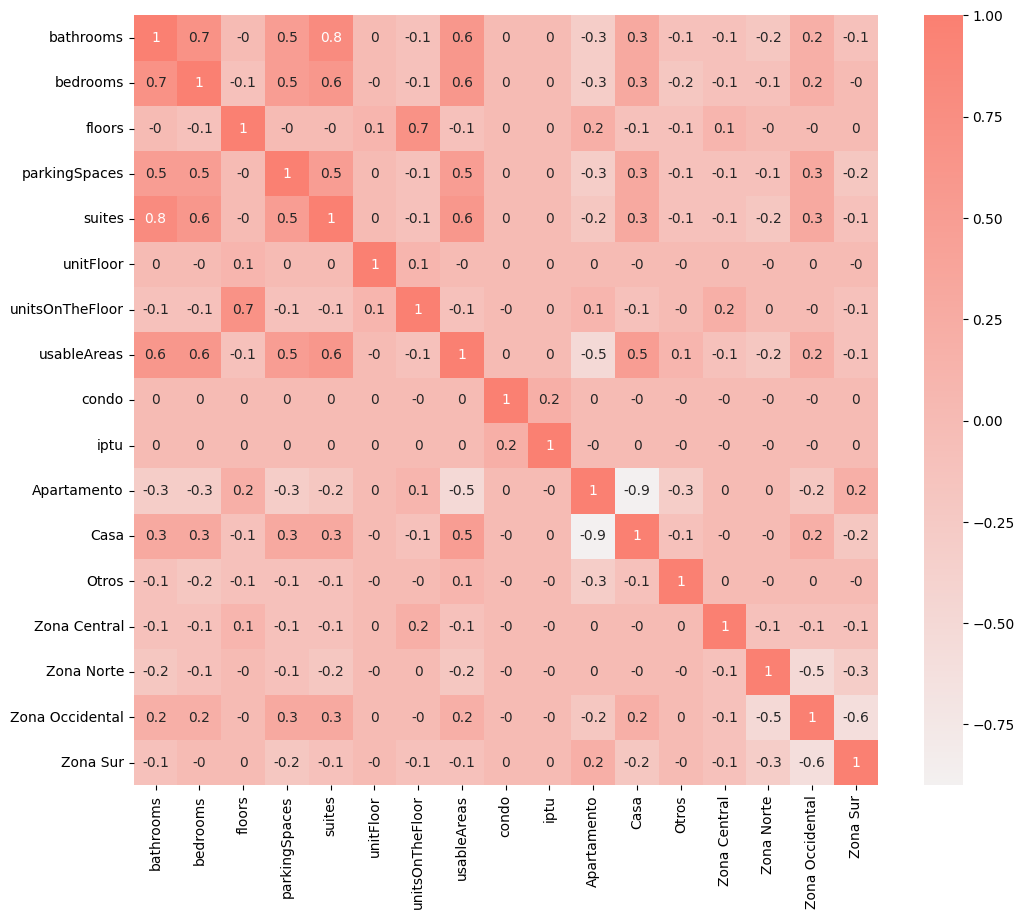

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
paleta = sns.color_palette('light:salmon',as_cmap=True)
sns.heatmap(df_correlacion.round(1),annot=True,cmap=paleta)
plt.show()

## **Ajuste y Previsión**

Documentación de: [randomSplit](https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/api/pyspark.sql.DataFrame.randomSplit.html) | [Regresión Lineal](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.LinearRegression.html)

In [ ]:
from pyspark.ml.regression import LinearRegression

In [ ]:
entrenamiento, test = dataset_prep.randomSplit([0.7,0.3],seed=101)

In [ ]:
entrenamiento.count()

48517

In [ ]:
test.count()

20922

In [ ]:
lr = LinearRegression()

In [ ]:
modelo_lr = lr.fit(entrenamiento)

In [ ]:
prevision_lr_entrenamiento = modelo_lr.transform(entrenamiento)

In [ ]:
prevision_lr_entrenamiento.show()

+--------------------+--------+------------------+
|            features|   label|        prediction|
+--------------------+--------+------------------+
|(17,[0,1,2,3,4,5,...|259000.0| 508929.2051174507|
|(17,[0,1,2,3,4,5,...|563500.0| 522600.3563433193|
|(17,[0,1,2,3,4,5,...|426000.0|486463.42780276213|
|(17,[0,1,2,3,4,5,...|419000.0| 476821.9416925624|
|(17,[0,1,2,3,4,5,...|255000.0|405054.14636754233|
|(17,[0,1,2,3,4,5,...|685000.0| 800878.5564688392|
|(17,[0,1,2,3,4,5,...|694000.0| 790169.8838441657|
|(17,[0,1,2,3,4,5,...|709000.0| 789783.3937890012|
|(17,[0,1,2,3,4,5,...|740000.0| 800169.9913677044|
|(17,[0,1,2,3,4,5,...|298000.0|  519555.575694532|
|(17,[0,1,2,3,4,5,...|465000.0|  505712.333053446|
|(17,[0,1,2,3,4,5,...|375000.0| 544121.7541886138|
|(17,[0,1,2,3,4,5,...|535000.0| 605236.2089352779|
|(17,[0,1,2,3,4,5,...|540000.0| 528316.5806429618|
|(17,[0,1,2,3,4,5,...|637000.0| 678964.0527032019|
|(17,[0,1,2,3,4,5,...|391300.0| 816204.3978487685|
|(17,[0,1,2,3,4,5,...|598000.0|

## **Métricas**

In [ ]:
resumen_entrenamiento = modelo_lr.summary

In [ ]:
resumen_entrenamiento.r2

0.6664632463397906

In [ ]:
resumen_entrenamiento.rootMeanSquaredError

802023.6291396681

In [ ]:
resumen_prueba = modelo_lr.evaluate(test)

In [ ]:
resumen_prueba.r2

0.6558855617532977

In [ ]:
resumen_prueba.rootMeanSquaredError

820858.5594258482

## **Resumen del modelo de Regresión Lineal**

In [ ]:
print('Regresión Lineal')
print("="*30)
print("Datos de Entrenamiento")
print("="*30)
print("R²: %f" % resumen_entrenamiento.r2)
print("RMSE: %f" % resumen_entrenamiento.rootMeanSquaredError)
print("")
print("="*30)
print("Datos de Prueba")
print("="*30)
print("R²: %f" % resumen_prueba.r2)
print("RMSE: %f" % resumen_prueba.rootMeanSquaredError)

Regresión Lineal
Datos de Entrenamiento
R²: 0.666463
RMSE: 802023.629140

Datos de Prueba
R²: 0.655886
RMSE: 820858.559426


# **Clase 3: Regresor de Árbol de Decisión**

Documentación de [Regresor de Árbol de Decisión](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.DecisionTreeRegressor.html)

<img src='https://github.com/ahcamachod/2313-spark-trabajando-con-regresion/blob/main/img/dtr.png?raw=True'>

## **Métricas**

Documentación de [Evaluador de Regresión](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.evaluation.RegressionEvaluator.html)

In [ ]:
print('Regresor de Árbol de Decisión')
print("="*30)
print("Datos de Entrenamiento")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_dtr_entrenamiento, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_dtr_entrenamiento, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Datos de Prueba")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_dtr_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_dtr_test, {evaluator.metricName: "rmse"}))

# **Clase 4: Regresor de Bosque Aleatorio**

<img src='https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif'>

## **Ajuste y Previsión**

Documentación de [Regresor de Bosque Aleatorio](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.regression.RandomForestRegressor.html)

## **Métricas**

In [ ]:
print('Regresor de Bosque Aleatorio')
print("="*30)
print("Datos de Entrenamiento")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_rfr_entrenamiento, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_rfr_entrenamiento, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Datos de Prueba")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_rfr_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_rfr_test, {evaluator.metricName: "rmse"}))

# **Clase 5: Técnicas de Optimización**

<img src='https://miro.medium.com/max/1400/1*kkMtezwv8qj1t9uG4nw_8g.png'>

## **Árbol de Decisión con Validación Cruzada**

Documentación de [CrossValidator](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.tuning.CrossValidator.html) | [ParamGridBuilder](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.tuning.ParamGridBuilder.html)

In [ ]:
print('Árbol de Decisión')
print("="*30)
print("Sin Validación Cruzada")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_dtr_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_dtr_test, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Con Validación Cruzada")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_dtr_cv_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_dtr_cv_test, {evaluator.metricName: "rmse"}))

## **Regresor de Bosque Aleatorio con Validación Cruzada**

In [ ]:
print('Bosque Aleatorio')
print("="*30)
print("Sin Validación Cruzada")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_rfr_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_rfr_test, {evaluator.metricName: "rmse"}))
print("")
print("="*30)
print("Con Validación Cruzada")
print("="*30)
print("R²: %f" % evaluator.evaluate(prevision_rfr_cv_test, {evaluator.metricName: "r2"}))
print("RMSE: %f" % evaluator.evaluate(prevision_rfr_cv_test, {evaluator.metricName: "rmse"}))

## **Previsión de Resultados con el mejor modelo**

In [ ]:
nuevo_inmueble = [{
 'bathrooms': 2,
 'bedrooms': 2,
 'floors': 2,
 'parkingSpaces': 1,
 'suites': 1,
 'unitFloor':0,
 'unitsOnTheFloor':0,
 'usableAreas':200,
 'condo':200,
 'iptu':0,
 'Apartamento':0,
 'Casa':1,
 'Otros':0,
 'Zona Central':0,
 'Zona Norte':0,
 'Zona Occidental':0,
 'Zona Sur':1,
 'label': 0}]